# Customer Intelligence System using Clustering and Ensemble Learning
**Celebal Technologies Data Science Internship | CEI**

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             silhouette_score)
from sklearn.neighbors import NearestNeighbors

try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Loading

In [2]:
df = pd.read_csv('Country-data.csv')
print(df.shape)
df.head(10)

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [5]:
print("Missing:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing: 0
Duplicates: 0


## EDA

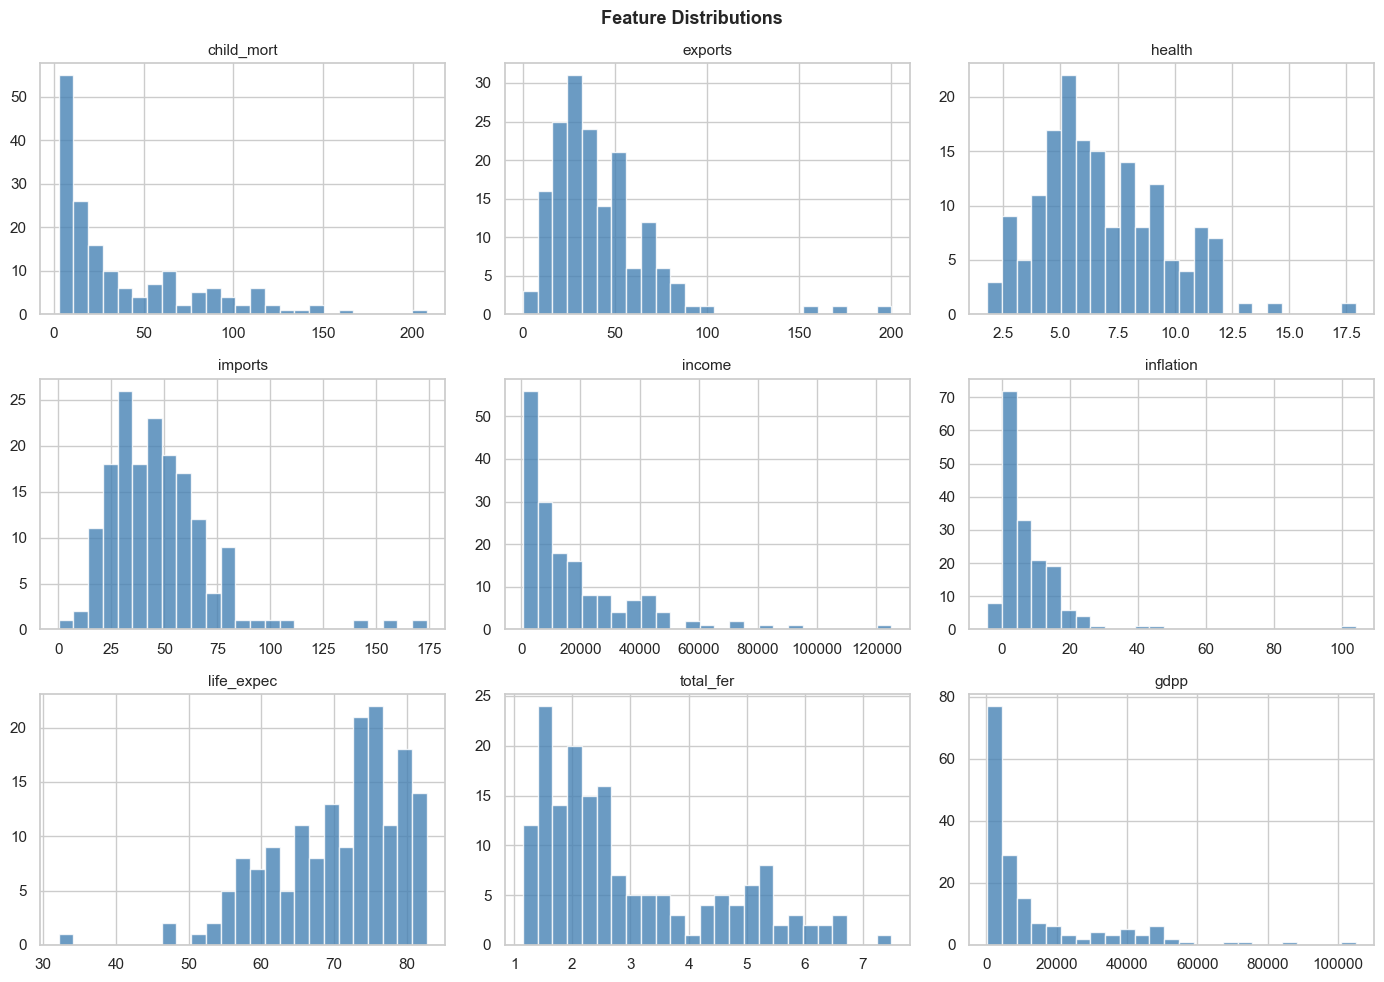

In [6]:
num_cols = [c for c in df.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11)
plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# child_mort, gdpp, income are heavily right-skewed — expected for global data

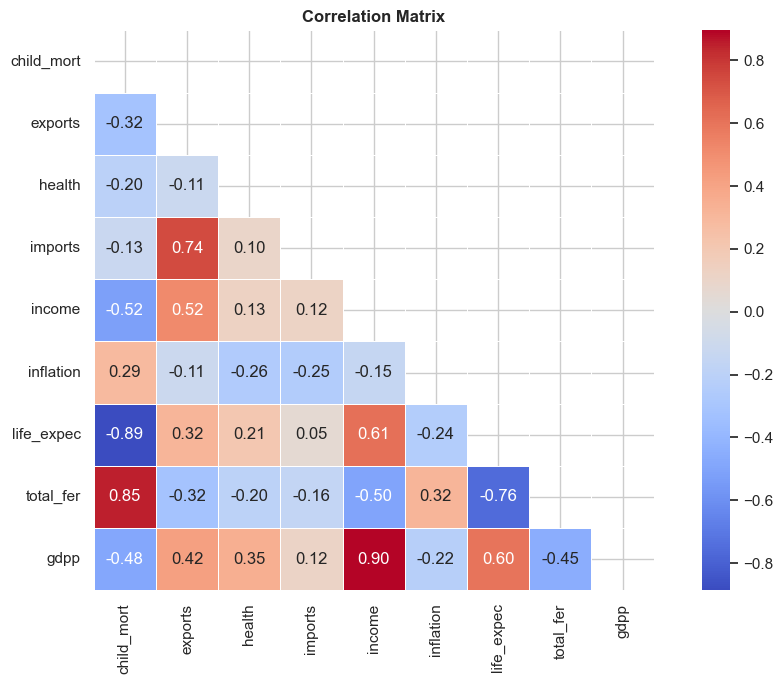

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=np.triu(np.ones((len(num_cols), len(num_cols)), dtype=bool)),
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()
# child_mort & life_expec are strongly negatively correlated (-0.89)
# gdpp & income are strongly positively correlated

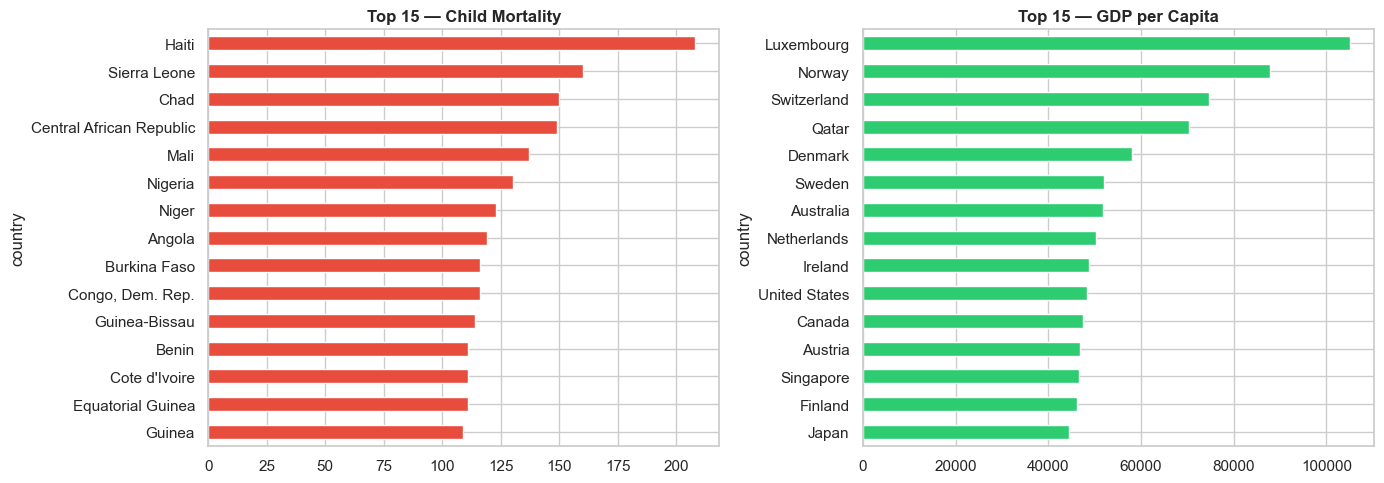

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.nlargest(15, 'child_mort').plot.barh(x='country', y='child_mort',
    ax=axes[0], color='#e74c3c', legend=False)
axes[0].set_title('Top 15 — Child Mortality', fontweight='bold')
axes[0].invert_yaxis()

df.nlargest(15, 'gdpp').plot.barh(x='country', y='gdpp',
    ax=axes[1], color='#2ecc71', legend=False)
axes[1].set_title('Top 15 — GDP per Capita', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

## Preprocessing

In [9]:
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])
X_df = pd.DataFrame(X_scaled, columns=num_cols)

print("Scaled shape:", X_df.shape)
X_df.describe().round(3).T[['mean', 'std']]

Scaled shape: (167, 9)


,mean,std
child_mort,-0.0,1.003
exports,0.0,1.003
health,0.0,1.003
imports,0.0,1.003
income,-0.0,1.003
inflation,-0.0,1.003
life_expec,0.0,1.003
total_fer,0.0,1.003
gdpp,0.0,1.003


## Feature Importance
Proxy development label built from GDP + income tertiles; Random Forest used to rank features.

In [10]:
# build a proxy label: 0=low, 1=mid, 2=high development
dev_score = (pd.qcut(df['gdpp'], 3, labels=[0,1,2]).astype(int)
           + pd.qcut(df['income'], 3, labels=[0,1,2]).astype(int))
y_dev = dev_score.apply(lambda s: 0 if s<=1 else (2 if s>=4 else 1))
print(y_dev.value_counts().sort_index())

0    61
1    54
2    52
Name: count, dtype: int64


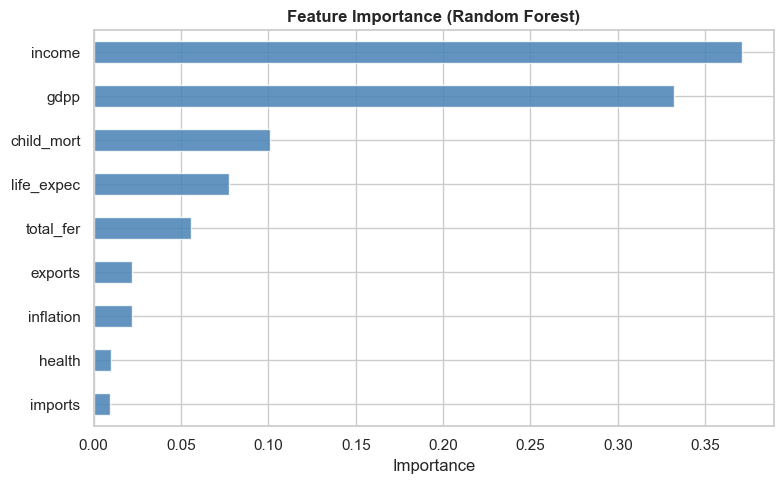

income        0.370847
gdpp          0.332078
child_mort    0.100900
life_expec    0.077493
total_fer     0.055675
exports       0.022093
inflation     0.021680
health        0.009813
imports       0.009422
dtype: float64


In [11]:
rf_imp = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_imp.fit(X_df, y_dev)

importances = pd.Series(rf_imp.feature_importances_, index=num_cols).sort_values()

plt.figure(figsize=(8, 5))
importances.plot.barh(color='steelblue', alpha=0.85)
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()

print(importances.sort_values(ascending=False))

## K-Means Clustering

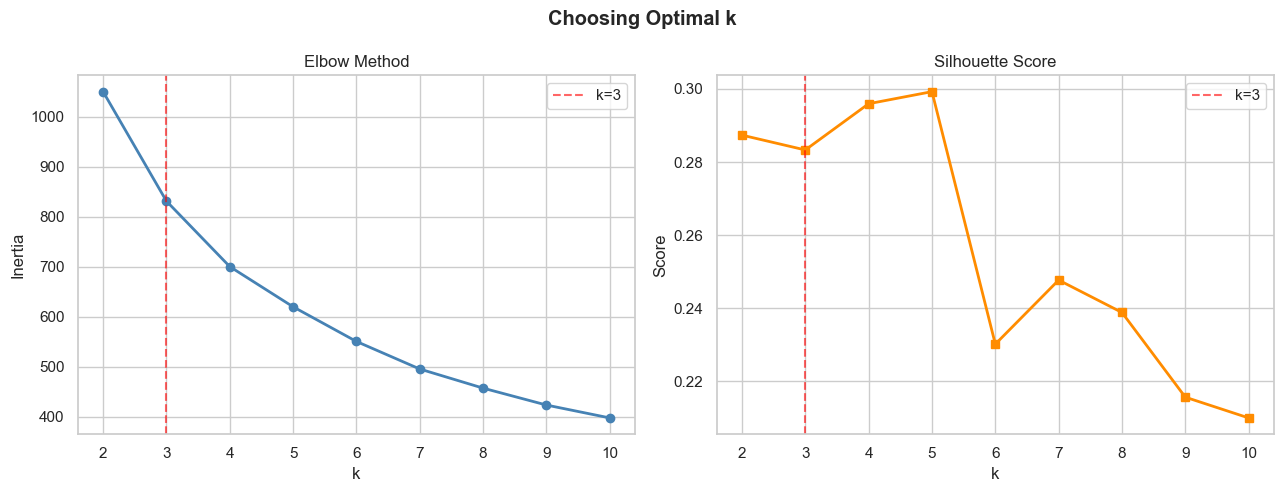

In [12]:
inertias, sil_scores = [], []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    lbls = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbls))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', lw=2)
ax1.axvline(3, color='red', ls='--', alpha=0.6, label='k=3')
ax1.set(title='Elbow Method', xlabel='k', ylabel='Inertia'); ax1.legend()

ax2.plot(list(K_RANGE), sil_scores, 's-', color='darkorange', lw=2)
ax2.axvline(3, color='red', ls='--', alpha=0.6, label='k=3')
ax2.set(title='Silhouette Score', xlabel='k', ylabel='Score'); ax2.legend()

plt.suptitle('Choosing Optimal k', fontweight='bold')
plt.tight_layout(); plt.show()
# k=3 gives clearest elbow and best silhouette score

In [13]:
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score (k={BEST_K}):", round(silhouette_score(X_scaled, df['cluster']), 4))
print(df['cluster'].value_counts().sort_index())

Silhouette Score (k=3): 0.2833
cluster
0    36
1    47
2    84
Name: count, dtype: int64


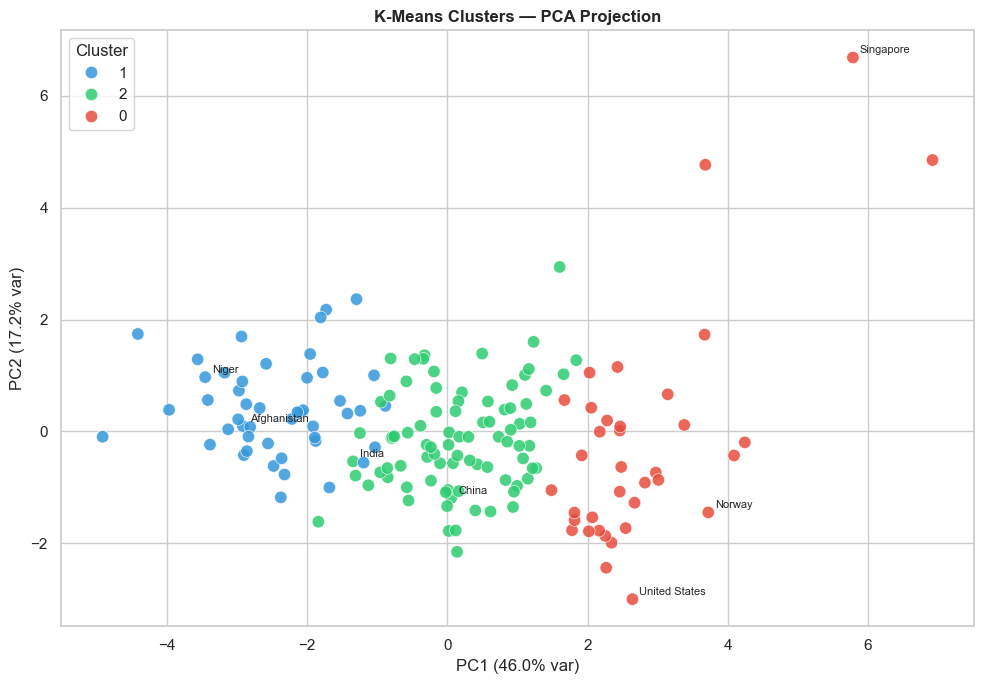

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

pca_df = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1],
                        'cluster': df['cluster'].astype(str),
                        'country': df['country']})

plt.figure(figsize=(10, 7))
palette = {'0':'#e74c3c', '1':'#3498db', '2':'#2ecc71'}
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster',
                palette=palette, s=80, alpha=0.85, edgecolors='w', lw=0.5)

for _, r in pca_df[pca_df['country'].isin(
    ['Afghanistan','Somalia','Niger','United States','Norway','Singapore','India','China'])].iterrows():
    plt.annotate(r['country'], (r['PC1'], r['PC2']),
                 textcoords='offset points', xytext=(5,3), fontsize=8)

plt.xlabel(f'PC1 ({ev[0]*100:.1f}% var)'); plt.ylabel(f'PC2 ({ev[1]*100:.1f}% var)')
plt.title('K-Means Clusters — PCA Projection', fontweight='bold')
plt.legend(title='Cluster'); plt.tight_layout(); plt.show()

In [15]:
# cluster profile — mean values per group
profile = df.groupby('cluster')[num_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [16]:
# label clusters by development level
def label_cluster(row):
    if row['gdpp'] > 20000: return 'Developed'
    if row['child_mort'] > 55: return 'Underdeveloped'
    return 'Developing'

cluster_map = profile.apply(label_cluster, axis=1).to_dict()
df['dev_category'] = df['cluster'].map(cluster_map)
df['priority'] = df['dev_category'].map({'Underdeveloped':'HIGH','Developing':'MEDIUM','Developed':'LOW'})
print(df['dev_category'].value_counts())

dev_category
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


## DBSCAN Clustering

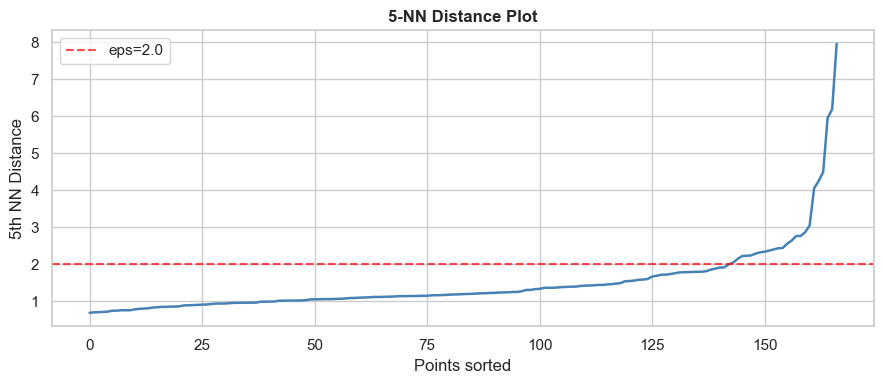

In [17]:
# k-distance plot to pick eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
kth = np.sort(dists[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(kth, color='steelblue', lw=1.8)
plt.axhline(2.0, color='red', ls='--', alpha=0.7, label='eps=2.0')
plt.title('5-NN Distance Plot', fontweight='bold')
plt.xlabel('Points sorted'); plt.ylabel('5th NN Distance')
plt.legend(); plt.tight_layout(); plt.show()

In [18]:
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['dbscan_lbl'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_lbl'])) - (1 if -1 in df['dbscan_lbl'].values else 0)
n_noise = (df['dbscan_lbl'] == -1).sum()
print(f"Clusters: {n_clusters}  |  Noise points: {n_noise}")
print(df['dbscan_lbl'].value_counts().sort_index())

Clusters: 1  |  Noise points: 15
dbscan_lbl
-1     15
 0    152
Name: count, dtype: int64


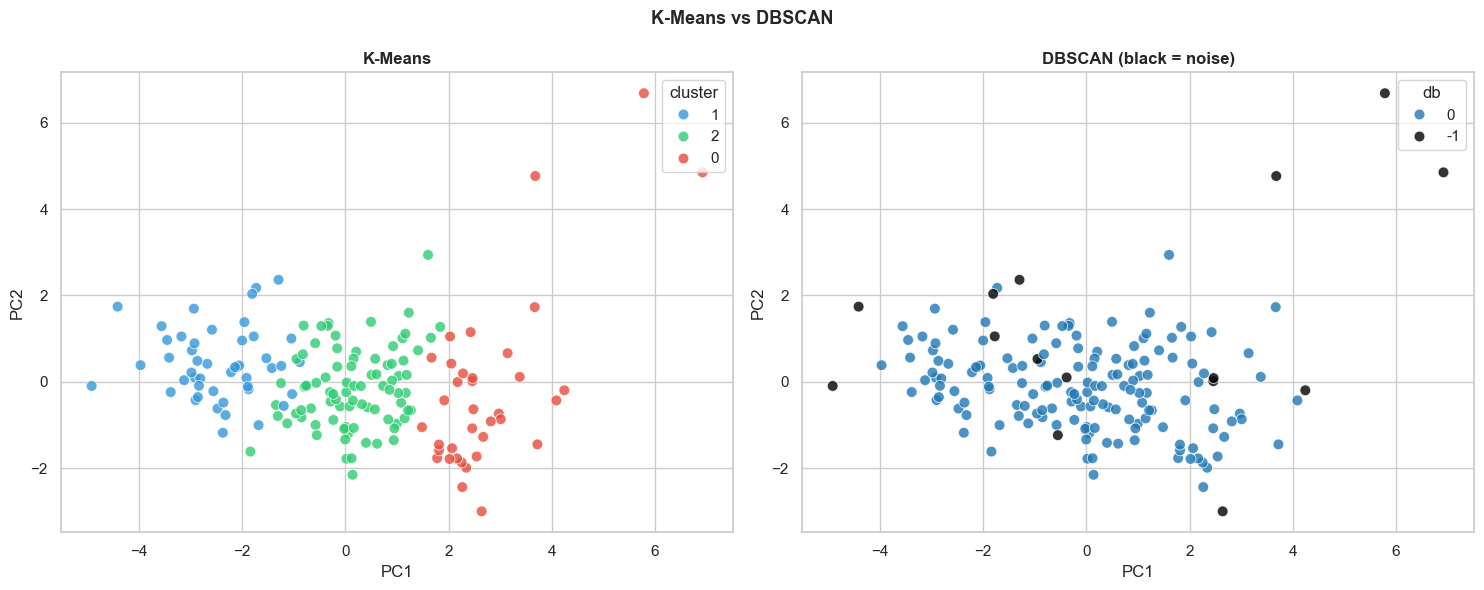

In [19]:
# DBSCAN vs K-Means in PCA space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

palette_km = {'0':'#e74c3c','1':'#3498db','2':'#2ecc71'}
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster',
                palette=palette_km, s=60, alpha=0.8, ax=ax1)
ax1.set_title('K-Means', fontweight='bold')

db_df = pca_df.copy(); db_df['db'] = df['dbscan_lbl'].astype(str)
unique_lbls = sorted(db_df['db'].unique())
pal_db = {l: ('black' if l=='-1' else sns.color_palette('tab10')[int(l)%10])
          for l in unique_lbls}
sns.scatterplot(data=db_df, x='PC1', y='PC2', hue='db',
                palette=pal_db, s=60, alpha=0.8, ax=ax2)
ax2.set_title('DBSCAN (black = noise)', fontweight='bold')

plt.suptitle('K-Means vs DBSCAN', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# DBSCAN finds fewer clean clusters but correctly marks outlier nations as noise

In [20]:
noise_countries = df[df['dbscan_lbl'] == -1]['country'].tolist()
print(f"Noise / outlier countries ({len(noise_countries)}):")
print(', '.join(noise_countries))

Noise / outlier countries (15):
Brunei, Equatorial Guinea, Haiti, Kuwait, Lesotho, Liberia, Luxembourg, Malta, Micronesia, Fed. Sts., Mongolia, Nigeria, Qatar, Singapore, United States, Venezuela


## Classification Models
K-Means cluster labels used as target for RF and XGBoost.

In [21]:
le = LabelEncoder()
y = le.fit_transform(df['cluster'])
X = X_df.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Class dist (test):", dict(zip(*np.unique(y_test, return_counts=True))))

Train: (125, 9) | Test: (42, 9)
Class dist (test): {0: 9, 1: 12, 2: 21}


In [22]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
cv_rf = cross_val_score(rf, X, y, cv=StratifiedKFold(5), scoring='accuracy')

print("=== Random Forest ===")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"CV Accuracy   : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"F1 (macro)    : {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Cluster 0','Cluster 1','Cluster 2']))

=== Random Forest ===
Test Accuracy : 1.0000
CV Accuracy   : 0.9638 ± 0.0297
F1 (macro)    : 1.0000

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         9
   Cluster 1       1.00      1.00      1.00        12
   Cluster 2       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



In [23]:
# XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                    eval_metric='mlogloss', random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
cv_xgb = cross_val_score(xgb, X, y, cv=StratifiedKFold(5), scoring='accuracy')

print("=== XGBoost ===")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"CV Accuracy   : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")
print(f"F1 (macro)    : {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=['Cluster 0','Cluster 1','Cluster 2']))

=== XGBoost ===
Test Accuracy : 0.9762
CV Accuracy   : 0.9579 ± 0.0240
F1 (macro)    : 0.9778

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         9
   Cluster 1       1.00      0.92      0.96        12
   Cluster 2       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



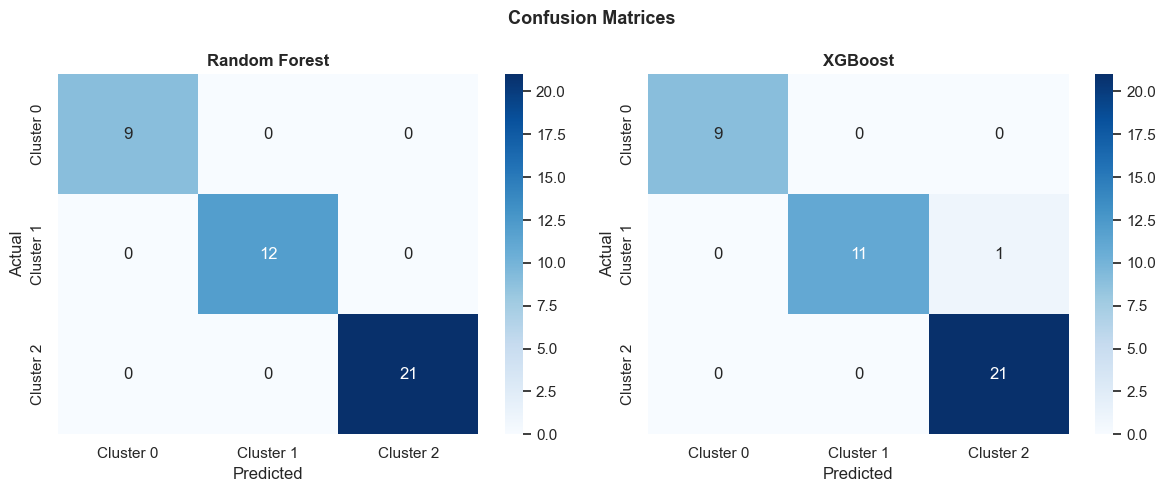

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lbls = ['Cluster 0','Cluster 1','Cluster 2']
for ax, y_pred, title in zip(axes,
                              [y_pred_rf, y_pred_xgb],
                              ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=lbls, yticklabels=lbls, ax=ax)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [25]:
# model comparison table
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Test Acc': [round(accuracy_score(y_test,y_pred_rf),4),
                 round(accuracy_score(y_test,y_pred_xgb),4)],
    'CV Acc': [round(cv_rf.mean(),4), round(cv_xgb.mean(),4)],
    'CV Std': [round(cv_rf.std(),4), round(cv_xgb.std(),4)],
    'Precision': [round(precision_score(y_test,y_pred_rf,average='macro'),4),
                  round(precision_score(y_test,y_pred_xgb,average='macro'),4)],
    'Recall': [round(recall_score(y_test,y_pred_rf,average='macro'),4),
               round(recall_score(y_test,y_pred_xgb,average='macro'),4)],
    'F1': [round(f1_score(y_test,y_pred_rf,average='macro'),4),
           round(f1_score(y_test,y_pred_xgb,average='macro'),4)],
}).set_index('Model')
results

,Test Acc,CV Acc,CV Std,Precision,Recall,F1
Model,,,,,,
Random Forest,1.0000,0.9638,0.0297,1.0000,1.0000,1.0000
XGBoost,0.9762,0.9579,0.0240,0.9848,0.9722,0.9778


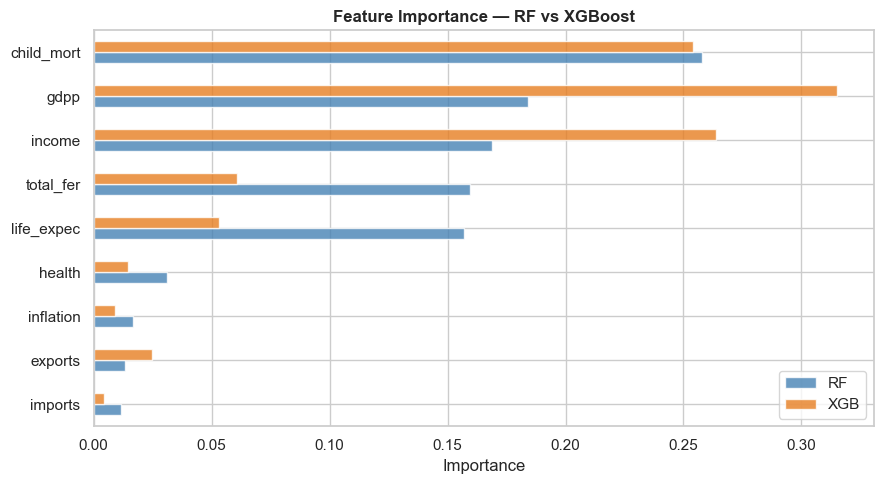

In [26]:
# feature importance comparison RF vs XGBoost
fi_rf  = pd.Series(rf.feature_importances_,  index=num_cols, name='RF')
fi_xgb = pd.Series(xgb.feature_importances_, index=num_cols, name='XGB')
fi_df  = pd.concat([fi_rf, fi_xgb], axis=1).sort_values('RF', ascending=True)

fi_df.plot.barh(figsize=(9, 5), color=['steelblue','#e67e22'], alpha=0.8)
plt.xlabel('Importance')
plt.title('Feature Importance — RF vs XGBoost', fontweight='bold')
plt.tight_layout(); plt.show()

## Model Comparison & Final Dashboard

In [27]:
dashboard = pd.DataFrame({
    'country':       df['country'],
    'cluster':       df['cluster'],
    'dev_category':  df['dev_category'],
    'priority':      df['priority'],
    'child_mort':    df['child_mort'].round(1),
    'income':        df['income'].round(0).astype(int),
    'life_expec':    df['life_expec'].round(1),
    'gdpp':          df['gdpp'].round(0).astype(int),
    'rf_pred':       le.inverse_transform(rf.predict(X_df)),
    'xgb_pred':      le.inverse_transform(xgb.predict(X_df)),
})

print("Dashboard shape:", dashboard.shape)
dashboard.head(20)

Dashboard shape: (167, 10)


,country,cluster,dev_category,priority,child_mort,income,life_expec,gdpp,rf_pred,xgb_pred
0,Afghanistan,1,Underdeveloped,HIGH,90.2,1610,56.2,553,1,1
1,Albania,2,Developing,MEDIUM,16.6,9930,76.3,4090,2,2
2,Algeria,2,Developing,MEDIUM,27.3,12900,76.5,4460,2,2
3,Angola,1,Underdeveloped,HIGH,119.0,5900,60.1,3530,1,1
4,Antigua and Barbuda,2,Developing,MEDIUM,10.3,19100,76.8,12200,2,2
5,Argentina,2,Developing,MEDIUM,14.5,18700,75.8,10300,2,2
6,Armenia,2,Developing,MEDIUM,18.1,6700,73.3,3220,2,2
7,Australia,0,Developed,LOW,4.8,41400,82.0,51900,0,0
8,Austria,0,Developed,LOW,4.3,43200,80.5,46900,0,0
9,Azerbaijan,2,Developing,MEDIUM,39.2,16000,69.1,5840,2,2


In [28]:
# countries that need the most attention
high_priority = (dashboard[dashboard['priority']=='HIGH']
                 .sort_values('child_mort', ascending=False)
                 .reset_index(drop=True))
print(f"HIGH priority countries: {len(high_priority)}")
high_priority[['country','dev_category','child_mort','gdpp','life_expec','income']].head(20)

HIGH priority countries: 47


,country,dev_category,child_mort,gdpp,life_expec,income
0,Haiti,Underdeveloped,208.0,662,32.1,1500
1,Sierra Leone,Underdeveloped,160.0,399,55.0,1220
2,Chad,Underdeveloped,150.0,897,56.5,1930
3,Central African Republic,Underdeveloped,149.0,446,47.5,888
4,Mali,Underdeveloped,137.0,708,59.5,1870
5,Nigeria,Underdeveloped,130.0,2330,60.5,5150
6,Niger,Underdeveloped,123.0,348,58.8,814
7,Angola,Underdeveloped,119.0,3530,60.1,5900
8,Burkina Faso,Underdeveloped,116.0,575,57.9,1430
9,"Congo, Dem. Rep.",Underdeveloped,116.0,334,57.5,609


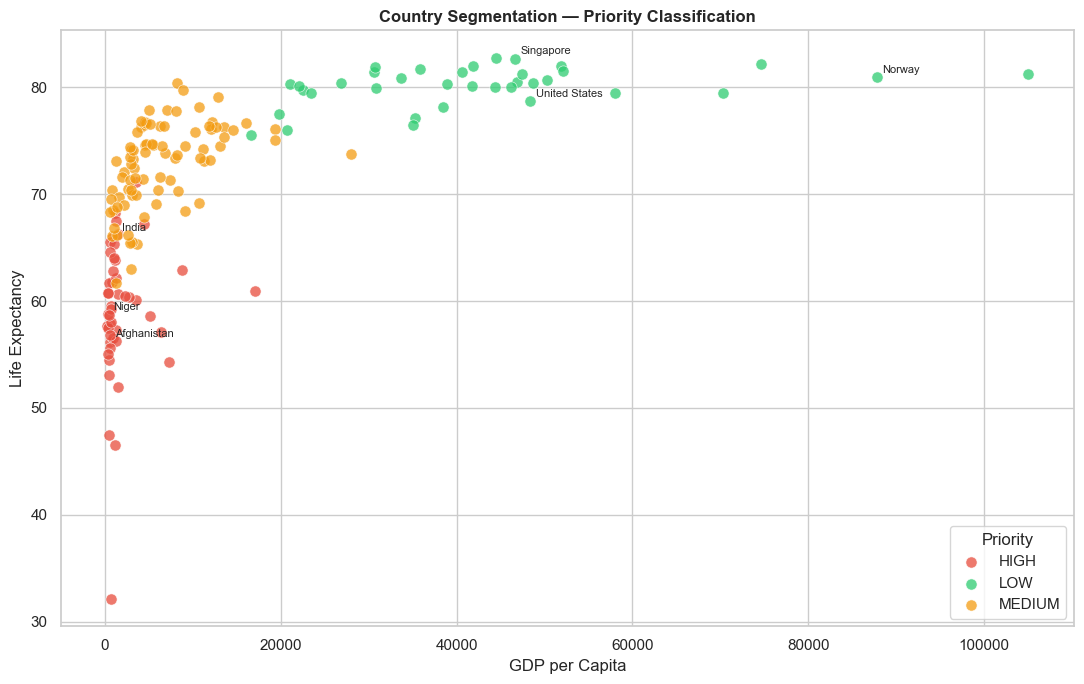

In [29]:
# scatter — GDP vs life expectancy coloured by priority
colors = {'HIGH':'#e74c3c','MEDIUM':'#f39c12','LOW':'#2ecc71'}

plt.figure(figsize=(11, 7))
for p, grp in dashboard.groupby('priority'):
    plt.scatter(grp['gdpp'], grp['life_expec'],
                label=p, color=colors[p], alpha=0.75, s=65,
                edgecolors='w', linewidths=0.5)

# label extreme cases
for _, r in dashboard[dashboard['country'].isin(
    ['Afghanistan','Niger','Somalia','United States','Norway','Singapore','India'])].iterrows():
    plt.annotate(r['country'], (r['gdpp'], r['life_expec']),
                 textcoords='offset points', xytext=(4,3), fontsize=8)

plt.xlabel('GDP per Capita'); plt.ylabel('Life Expectancy')
plt.title('Country Segmentation — Priority Classification', fontweight='bold')
plt.legend(title='Priority'); plt.tight_layout(); plt.show()

In [30]:
# save final output
dashboard.to_csv('country_intelligence_output.csv', index=False)
print("Saved: country_intelligence_output.csv")
print("\nPriority distribution:")
print(dashboard['priority'].value_counts())
print("\nDevelopment category:")
print(dashboard['dev_category'].value_counts())

Saved: country_intelligence_output.csv

Priority distribution:
priority
MEDIUM    84
HIGH      47
LOW       36
Name: count, dtype: int64

Development category:
dev_category
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64
